# **TP3 - Redes Neuronales**
## Redes Neuronales Convolucionales (CNN)
#### Dataset: Dogs vs Cats

------------------------
------------------------
**Instrucciones:**

- **No** modificar las celdas de texto.

- Resolver cada consigna en su sección correspondiente. Pueden sumar celdas de código y texto si lo consideran necesario. Recuerden que lo más importante es el razonamiento y justificación de los pasos para demostrar comprensión del problema a resolver.

- **ENTREGA:** Ir a Archivo > Descargar .ipynb. Este archivo .ipynb deberán subirlo al campus junto con las diapositivas en formato PDF (archivo no editable) hasta las 23:59hs del día anterior a la presentación. La presentación oral de este último documento será de manera grupal en hasta 10 minutos  durante el horario de clase (anunciaremos el orden de los grupos en el campus).

------------------------
------------------------

# **Objetivo:** Entrenar una CNN para clasificación binaria entre gatos y perros

El dataset que usaremos fue armado para una competencia de Kaggle en 2013, donde se premiaba al mejor modelo capaz de distinguir entre fotos de gatos y perros. Los modelos ganadores alcanzaron una accuracy de ~95%.

## Carga de datos y pre-procesado

El dataset original tiene 25.000 imágenes. Acá trabajaremos con un subset de 12500 imágenes, que las subimos a github así lo cargan facilmente.

Trabajaremos con el siguiente split:
- Train: 9500
- Validation: 1000
- Test: 2000

In [36]:
!git clone https://github.com/yohanncorfdir/SIA22.71

fatal: destination path 'SIA22.71' already exists and is not an empty directory.


In [37]:
import os
import cv2
import numpy as np
from sklearn.utils import shuffle
from tensorflow import keras
import tensorflow as tf

data_root = "./SIA22.71/PetImages"
classes = ["Cat", "Dog"]

# El dataset original tiene imágenes de distintos tamaños en formato JPG
size = (128, 128) # Vamos a redimensionar las imagenes a 128x128

X = []
y = []

for label, cls in enumerate(classes):
    folder = os.path.join(data_root, cls)
    files = sorted([f for f in os.listdir(folder) if f.lower().endswith(".jpg")])

    for filename in files:
        path = os.path.join(folder, filename)
        img = cv2.imread(path)
        if img is None:
            continue
        img = cv2.resize(img, dsize = size)
        X.append(img)
        y.append(label)  # Etiqueta 0 para gatos, 1 para perros
X = np.array(X)
y = np.array(y)

# Shuffle dataset
X, y = shuffle(X, y, random_state=42)

X_train, y_train = X[:9500], y[:9500]
X_val, y_val = X[9500:10500], y[9500:10500]
X_test, y_test = X[10500:12500], y[10500:12500]

print(f"Train:\t\t {len(X_train)} images")
print(f"Validation:\t {len(X_val)} images")
print(f"Test:\t\t {len(X_test)} images")
print(f"Image shape:\t {X_train[0].shape}")

Corrupt JPEG data: 239 extraneous bytes before marker 0xd9
Corrupt JPEG data: 214 extraneous bytes before marker 0xd9
Corrupt JPEG data: 128 extraneous bytes before marker 0xd9
Corrupt JPEG data: 99 extraneous bytes before marker 0xd9
Corrupt JPEG data: 399 extraneous bytes before marker 0xd9
Corrupt JPEG data: 226 extraneous bytes before marker 0xd9
Corrupt JPEG data: 162 extraneous bytes before marker 0xd9
Corrupt JPEG data: 1403 extraneous bytes before marker 0xd9
Corrupt JPEG data: 254 extraneous bytes before marker 0xd9


Train:		 9500 images
Validation:	 1000 images
Test:		 2000 images
Image shape:	 (128, 128, 3)


Algunas imágenes de ejemplo:

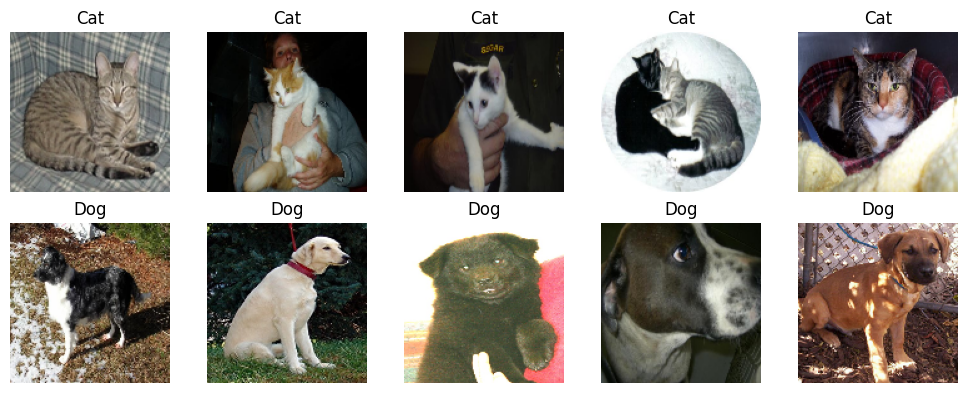

In [38]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i in range(5):
    axes[0, i].imshow(cv2.cvtColor(X_train[y_train==0][i], cv2.COLOR_BGR2RGB))
    axes[0, i].set_title("Cat")
    axes[0, i].axis('off')
    axes[1, i].imshow(cv2.cvtColor(X_train[y_train==1][i], cv2.COLOR_BGR2RGB))
    axes[1, i].set_title("Dog")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

# Lineamiento general:
Para este último TP daremos lineamientos más generales, confiamos en que ya conocen el *workflow* del aprendizaje automático. Este dataset no requiere practicamente exploración/limpieza y ya está casi listo para entrenar. Además ya les damos los splits armados. Mantengan el código simple y limpio, deberían poder hacer todo con las herramientas vistas en las notebooks de las clases.

Los requerimientos que hay que cumplir son:
## 1) Modelo inicial:
*  Entrenar una CNN para clasificar las fotos de perros y gatos. Explicar claramente qué entra a la red, qué sale, cuales son las capas y qué hace cada una. Justificar la elección de las funciones de costo, activaciones interna y activación de salida.
*   Optimizar la red dentro de lo posible, explicando el método de optimización utilizado, espacio de búsqueda. Reportar la arquitectura final de la red y cantidad de parámetros.
*   Para el modelo final, reportar claramente los resultados en el conjunto de test.
*   Visualizar los feature maps creados por la primera capa del modelo para alguna imagen de un perro y una de un gato.

## 2) Modelo con data augmentation:

El *data augmentation* es una técnica que incrementa artificialmente la cantidad y diversidad
de los datos de entrenamiento generando versiones modificadas de las imágenes existentes.
Su objetivo principal es mejorar la generalización del modelo y reducir el sobreajuste
(*overfitting*), siendo especialmente útil cuando el conjunto de datos es limitado.

Para imágenes, las transformaciones más comunes incluyen rotaciones, zoom, traslaciones,
recortes, volteos horizontales y cambios de brillo, entre otras.
*   Incorporar data augmentation a su pipeline de entrenamiento. Justificar qué transformaciones eligieron y por qué tienen sentido para este dataset en particular.
*   Comparar el rendimiento del modelo con y sin data augmentation sobre el conjunto de validación y testeo. ¿Se observa una reducción del overfitting en las curvas de entrenamiento?

## 3) Prueben su sistema en datos propios

*  Utilicen una o varias fotos de sus mascotas para probar su mejor modelo.

Primero llevamos a cabo un pequeno Preprocesado de los datos

In [39]:
# ¿Como son los datos?
print(f"Forma de los datos: {X_train[0].shape}")
print(f"Tipo de datos: {X_train[0].dtype}")
print(f"Rango de valores: [{X_train.min()}, {X_train.max()}]")
print(f"Etiquetas: {np.unique(y_train)}")

Forma de los datos: (128, 128, 3)
Tipo de datos: uint8
Rango de valores: [0, 255]
Etiquetas: [0 1]


In [40]:
X_train, X_val, X_test = X_train / 255., X_val / 255., X_test / 255.
print(f"Rango de valores antes: [0, 255]")
print(f"Rango de valores después: [{X_train.min()}, {X_train.max()}]")

# Para clasificación binaria con activación sigmoide en la salida,
# no es necesario codificar las etiquetas en one-hot. Usaremos
# directamente las etiquetas binarias y_train, y_val y y_test (0: Cat, 1: Dog).
print(f"Ejemplo - Etiqueta original: {y_train[0]}")


Rango de valores antes: [0, 255]
Rango de valores después: [0.0, 1.0]
Ejemplo - Etiqueta original: 0


In [ ]:
from keras import layers
keras.utils.set_random_seed(812)  # fijo la random seed de tensorflow para que el resultado sea reproducible

model = tf.keras.Sequential([
    layers.Input(shape=[128, 128, 3]), # Capa de entrada

    # 1ra capa convolucional + Batch Normalization + ReLU + MaxPool2D (sin Dropout)
    layers.Conv2D(filters=32, kernel_size=3, padding="same", kernel_initializer="he_normal"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPool2D(),

    # 2da capa convolucional + Batch Normalization + ReLU + MaxPool2D (sin Dropout)
    layers.Conv2D(filters=64, kernel_size=3, padding="same", kernel_initializer="he_normal"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPool2D(),

    # 3ra capa convolucional + Batch Normalization + ReLU + MaxPool2D (sin Dropout)
    layers.Conv2D(filters=128, kernel_size=3, padding="same", kernel_initializer="he_normal"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPool2D(),

    # 4ta capa convolucional + Batch Normalization + ReLU + MaxPool2D (sin Dropout)
    layers.Conv2D(filters=256, kernel_size=3, padding="same", kernel_initializer="he_normal"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPool2D(),

    # Ahora el MLP (fully connected). La primera capa aplana la entrada.
    layers.Flatten(),

    layers.Dense(units=64, activation="relu", kernel_initializer="he_normal"),   # 1ra capa densa, 64 neuronas
    layers.Dropout(0.3),                                                         # Capa de Dropout para regularización en el clasificador

    layers.Dense(units=32, activation="relu", kernel_initializer="he_normal"),   # 2da capa densa, 32 neuronas
    layers.Dropout(0.3),                                                         # Otra capa de Dropout

    layers.Dense(units=1, activation="sigmoid")                       # Capa de salida (1 unidad, activación sigmoide para clasificación binaria)
    ])

model.summary()


Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_15 (Conv2D)          (None, 128, 128, 32)      896       
                                                                 
 batch_normalization_3 (Bat  (None, 128, 128, 32)      128       
 chNormalization)                                                
                                                                 
 activation_3 (Activation)   (None, 128, 128, 32)      0         
                                                                 
 max_pooling2d_15 (MaxPooli  (None, 64, 64, 32)        0         
 ng2D)                                                           
                                                                 
 conv2d_16 (Conv2D)          (None, 64, 64, 64)        18496     
                                                                 
 batch_normalization_4 (Bat  (None, 64, 64, 64)       

In [42]:
# Usemos el optimizador Adam con un learning rate de 0.001
optimizador = tf.keras.optimizers.Adam(learning_rate=0.001)

model.compile(
    optimizer=optimizador,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Early stopping con patience=10 en la loss de validación,
# y nos quedamos con los pesos del menor loss de validación (no los de la última epoca)
early_stopping_cb = tf.keras.callbacks.EarlyStopping(monitor='val_loss',
                                                     patience=10,
                                                     restore_best_weights=True)

# ReduceLROnPlateau para reducir el learning rate cuando la val_loss se estanque
reduce_lr_cb = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss',
                                                    factor=0.2,
                                                    patience=5,
                                                    min_lr=0.00001,
                                                    verbose=1)

historia = model.fit(
    X_train,
    y_train,
    epochs=200,
    batch_size=128,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping_cb, reduce_lr_cb],
    verbose=1
)


Epoch 1/200


2026-06-04 20:14:48.737488: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


75/75 [==============================] - ETA: 0s - loss: 51.6547 - accuracy: 0.4978

2026-06-04 20:15:11.360638: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


75/75 [==============================] - 24s 301ms/step - loss: 51.6547 - accuracy: 0.4978 - val_loss: 20.1282 - val_accuracy: 0.4550 - lr: 0.0010
Epoch 2/200
75/75 [==============================] - 21s 286ms/step - loss: 36.2290 - accuracy: 0.5088 - val_loss: 41.9591 - val_accuracy: 0.4840 - lr: 0.0010
Epoch 3/200
75/75 [==============================] - 21s 282ms/step - loss: 29.1744 - accuracy: 0.5325 - val_loss: 23.7014 - val_accuracy: 0.4980 - lr: 0.0010
Epoch 4/200
75/75 [==============================] - 21s 277ms/step - loss: 21.0331 - accuracy: 0.5546 - val_loss: 34.3328 - val_accuracy: 0.4860 - lr: 0.0010
Epoch 5/200
75/75 [==============================] - 21s 285ms/step - loss: 16.3897 - accuracy: 0.5713 - val_loss: 4.7570 - val_accuracy: 0.6170 - lr: 0.0010
Epoch 6/200
75/75 [==============================] - 20s 271ms/step - loss: 13.9265 - accuracy: 0.5708 - val_loss: 10.5813 - val_accuracy: 0.5430 - lr: 0.0010
Epoch 7/200
75/75 [==============================] - 20s 27

In [43]:
# ========================================== 
# Evaluación en el conjunto de test
# ========================================== 
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=1)
print(f"\nResultados finales en el conjunto de test:")
print(f"Pérdida (Loss): {test_loss:.4f}")
print(f"Precisión (Accuracy): {test_accuracy*100:.2f}%")


63/63 [==============================] - 2s 21ms/step - loss: 0.3631 - accuracy: 0.8435

Resultados finales en el conjunto de test:
Pérdida (Loss): 0.3631
Precisión (Accuracy): 84.35%


1/1 [==============================] - 0s 11ms/step


2026-06-05 10:16:53.195065: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


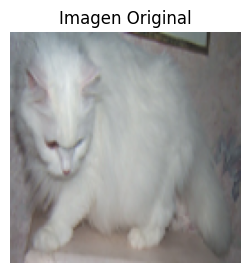

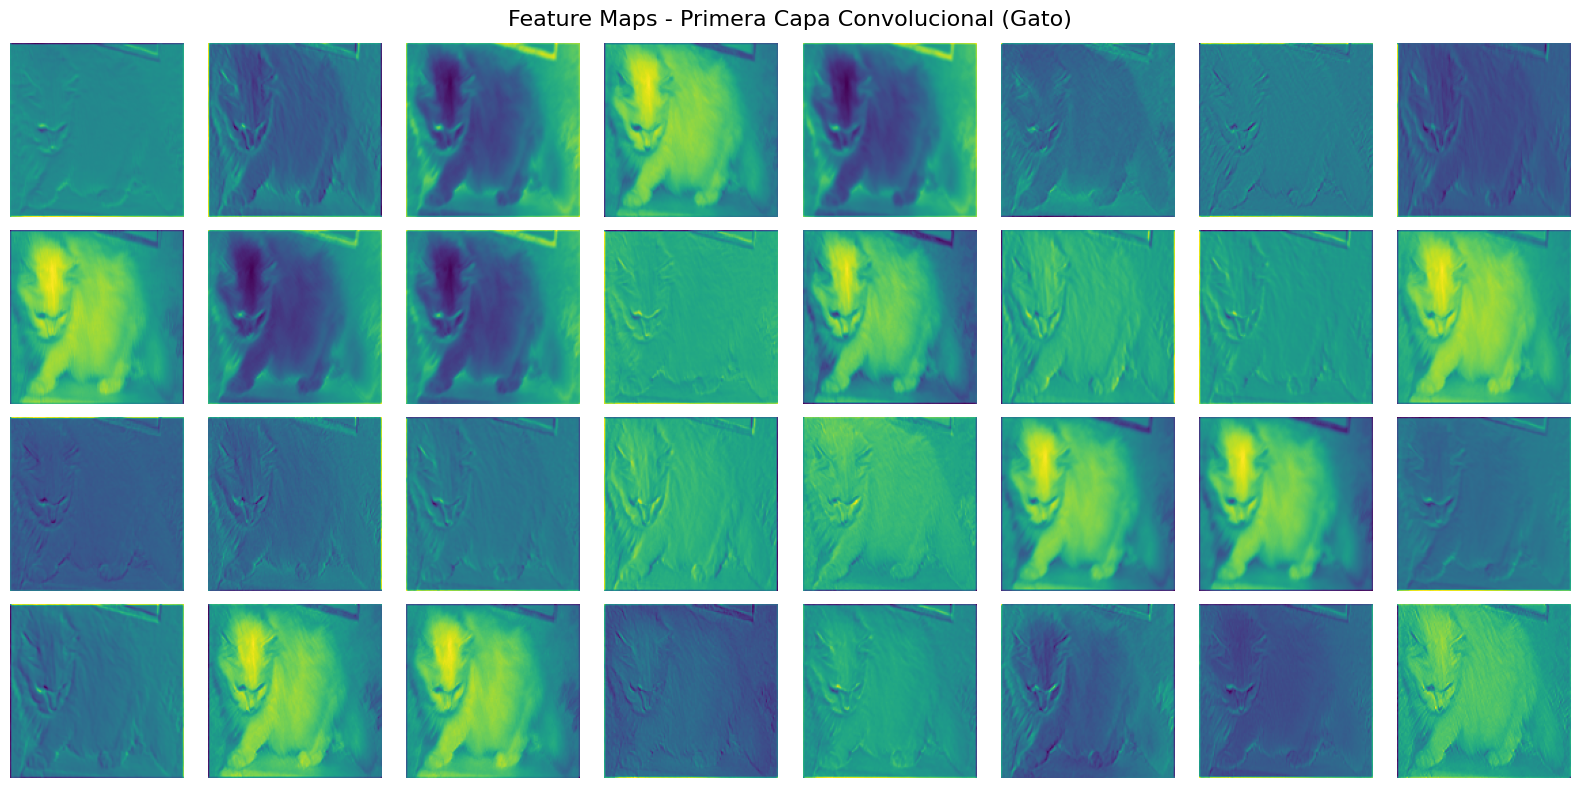

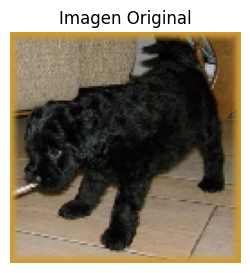

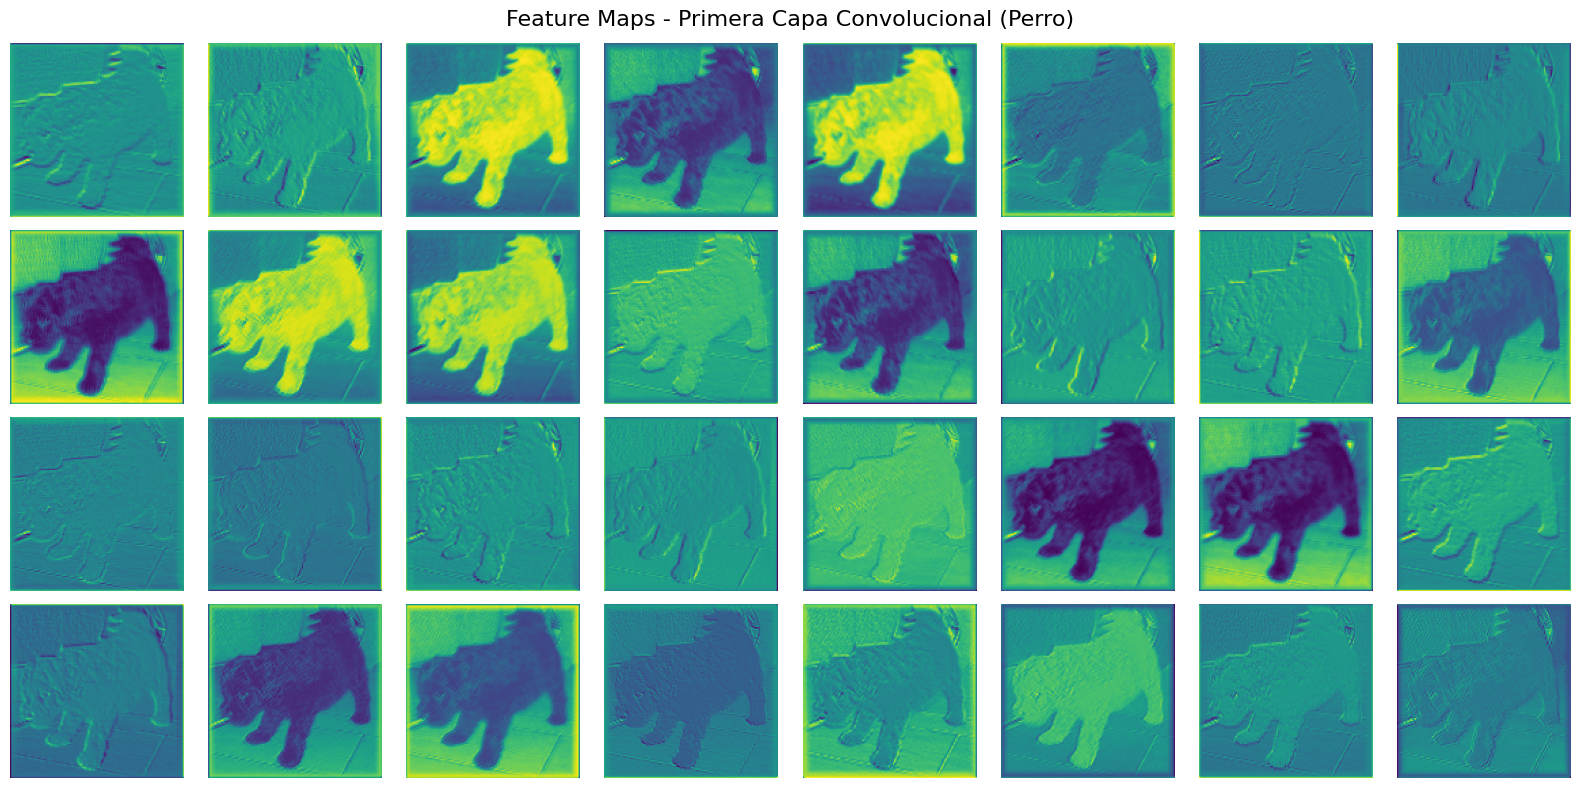

In [ ]:
# ========================================== 
# Visualización de los Feature Maps (primera capa)
# ========================================== 
import matplotlib.pyplot as plt

# 1. Definir un submodelo que devuelva la activación de la primera capa convolucional
conv_layer = [layer for layer in model.layers if isinstance(layer, tf.keras.layers.Conv2D)][0]
activation_model = tf.keras.Model(inputs=model.input, outputs=conv_layer.output)

# 2. Tomar una imagen de un gato (y=0) y una de un perro (y=1) del conjunto de testeo
cat_idx = np.where(y_test == 0)[0][0]
dog_idx = np.where(y_test == 1)[0][0]

cat_img = X_test[cat_idx]
dog_img = X_test[dog_idx]

# 3. Obtener los feature maps (activaciones)
# Expandimos dimensiones para que tenga el tamaño de lote (batch size = 1) -> (1, 128, 128, 3)
cat_activations = activation_model.predict(np.expand_dims(cat_img, axis=0))
dog_activations = activation_model.predict(np.expand_dims(dog_img, axis=0))

# 4. Función para graficar los 32 feature maps generados por los 32 filtros
def plot_feature_maps(activations, original_img, title):
    # Mostrar primero la imagen original
    plt.figure(figsize=(3, 3))
    plt.imshow(cv2.cvtColor((original_img * 255).astype(np.uint8), cv2.COLOR_BGR2RGB))
    plt.title("Imagen Original")
    plt.axis('off')
    plt.show()

    # Mostrar los 32 feature maps en una grilla de 4x8
    fig, axes = plt.subplots(4, 8, figsize=(16, 8))
    fig.suptitle(title, fontsize=16)
    for i in range(32):
        ax = axes[i // 8, i % 8]
        # Tomamos el i-ésimo canal del output convolucional
        ax.imshow(activations[0, :, :, i], cmap='viridis')
        ax.axis('off')
    plt.tight_layout()
    plt.show()

# Graficar los mapas para el gato y el perro
plot_feature_maps(cat_activations, cat_img, "Feature Maps - Primera Capa Convolucional (Gato)")
plot_feature_maps(dog_activations, dog_img, "Feature Maps - Primera Capa Convolucional (Perro)")
